In [1]:
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from fed_env import FedEnvBase, MockLLMObservationWrapper

## PPO Agent Baseline (No LSTM)

### RL Hyperparameter Justification

* **`total_timesteps = 100,000`**: Our episodes are exactly 60 steps long. 100,000 timesteps equals roughly 1,666 episodes of training. Because our state space is relatively low-dimensional (3 macro features + 5 LLM text features = 8 dimensions) and our action space is discrete (7 choices), 1,666 episodes is the sweet spot.
* **`n_steps = 2048`**: This is the rollout buffer size. It dictates how much experience the agent collects in the environment before pausing to update its neural network weights. Since our episode is 60 steps, `2048 / 60 ≈ 34` full episodes.
* **`batch_size = 64`**: During the network update, PPO shuffles the 2048 steps and pulls batches of 64 to compute the loss.
* **`learning_rate = 0.0005`**: The Stable-Baselines3 PPO default is 0.0003. We slightly bumped it up because our quadratic reward structure provides a very clean, convex loss surface.

In [2]:
def train_and_evaluate_ppo():
    # Init wrapped environment
    base_env = FedEnvBase(llm_dim=5)
    env = MockLLMObservationWrapper(base_env)

    # Train standard PPO agent
    model = PPO(
        "MultiInputPolicy", env, learning_rate=0.0005, n_steps=2048,
        batch_size=64, verbose=0, seed=42
    )
    model.learn(total_timesteps=1000000)

    # Eval
    obs, _ = env.reset(seed=42)

    # extract the dynamic shock schedule for accurate plotting
    shock_start = env.unwrapped.shock_start
    shock_end = env.unwrapped.shock_end

    history_rl = {"pi": [], "u": [], "rate": [], "reward": []}
    total_reward = 0

    for _ in range(60):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(int(action))

        history_rl["pi"].append(obs["macro"][0])
        history_rl["u"].append(obs["macro"][1])
        history_rl["rate"].append(obs["macro"][2])
        history_rl["reward"].append(reward)
        total_reward += reward

    print(f'Vanilla PPO Total Reward: {total_reward:.2f}')

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ax1.plot(history_rl["pi"], label="AI Inflation (%)", color="red", linewidth=2)
    ax1.plot(history_rl["u"], label="AI Unemployment (%)", color="blue", linewidth=2)
    ax1.axvspan(shock_start, shock_end, color='gray', alpha=0.2, label="Supply Shock")
    ax1.axhline(2.0, color='red', linestyle='--'); ax1.axhline(4.0, color='blue', linestyle='--')
    ax1.set_title(f"PPO Agent (No LSTM) | Total Reward: {total_reward:.2f}", fontweight='bold')
    ax1.legend(loc="upper left"); ax1.grid(True)

    ax2.step(range(len(history_rl["rate"])), history_rl["rate"], label="AI Policy Rate", color="purple", linewidth=2, where='post')
    ax2.axvspan(shock_start, shock_end, color='gray', alpha=0.2)
    ax2.legend(loc="upper left"); ax2.grid(True)
    plt.tight_layout()
    plt.show()

Vanilla PPO Total Reward: -195.39


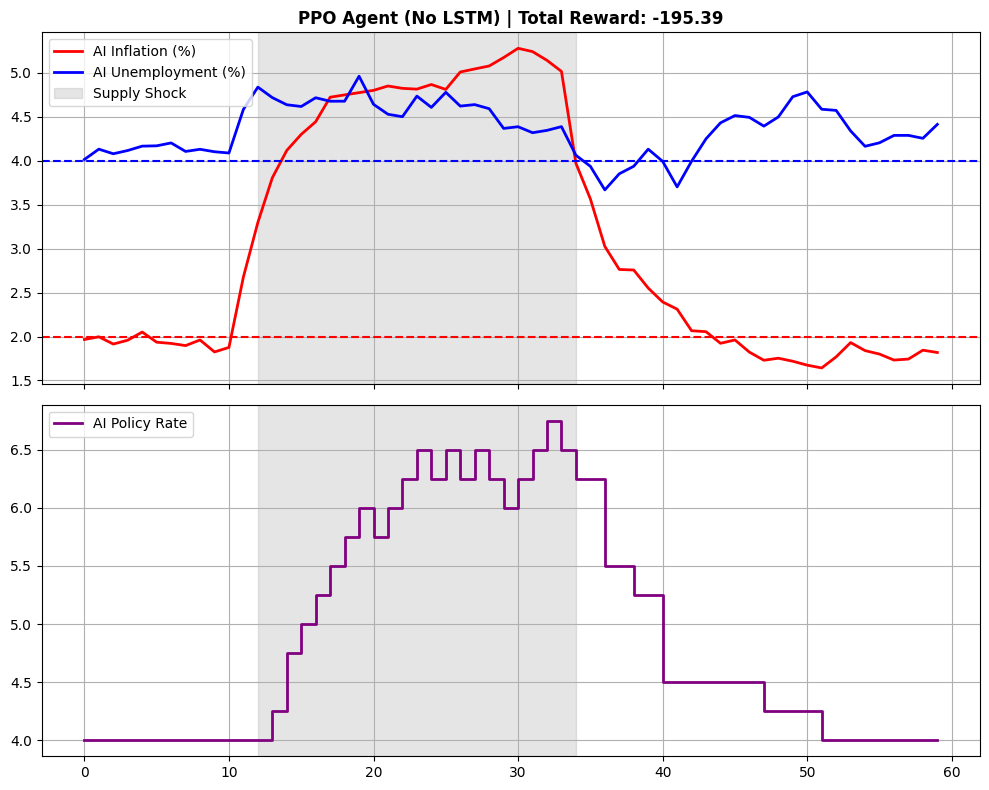

In [3]:
train_and_evaluate_ppo()